In [1]:
%pip install thefuzz

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from thefuzz import process, fuzz

inventory = pd.read_csv('../Data/inventory_stock.csv')
sales_pos = pd.read_csv('../Data/raw_sales_pos.csv')
recipes = pd.read_csv('../Data/recipe_book_unstandardized.csv')
invoices = pd.read_csv('../Data/supplier_invoices.csv')
# benchmark only food, drink needed
benchmark = pd.read_csv('../Data/benchmark_ingredienti_horeca.csv')

# CONSTANT VARIABLES
PREMIUM_CATEGORIES = ['zafferano', 'tartufo', 'caviale', 'vaniglia']

# Safe categories where >€10/g is always error
SAFE_CATEGORIES = ['carni', 'verdure', 'latticini']

# Ingredients standardized dict
MAPPING_DICT = {# condimenti
                'olio ev': 'olio extravergine oliva','olio evo':'olio extravergine oliva',
                'olio evo lt': 'olio extravergine oliva', 'sale 100/kg': 'sale fino',
                # uova
                'uova 30pz': 'uova fresche', 'uova xl': 'uova fresche',
                # carne
                'fil. manzo': 'filetto di manzo',
                # pesce
                'salmone inter': 'salmone', 'salmone intero': 'salmone','salmoneo':'salmone', 
                # latticini
                'parm.regg.':'parmigiano reggiano'}

CONVERSION_MAP = {'burrata': (0.125, 'pz', 'kg'),
                  'uova':( 0.06, 'pz', 'kg'),
                  'panna fresca liquida': (1.0, ['bt', '750ml', '0.75'], 'lt')
                  }

ALLOWED_UNITS = {'kg', 'lt'}

# quick look on dfs info
print("Inventory Stock Info:")
inventory.info()
print("\nSales POS Info:")
sales_pos.info()
print("\nRecipes Info:")
recipes.info()
print("\nInvoices Info:")
invoices.info()

Inventory Stock Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   inventario_id      576 non-null    int64  
 1   data_rilevazione   576 non-null    object 
 2   prodotto           576 non-null    object 
 3   categoria          556 non-null    object 
 4   ubicazione         576 non-null    object 
 5   qty_teorica        576 non-null    float64
 6   qty_fisica         525 non-null    float64
 7   unita_misura       576 non-null    object 
 8   valore_unitario    538 non-null    float64
 9   valore_totale_eur  538 non-null    float64
 10  operatore          490 non-null    object 
 11  note_rettifica     193 non-null    object 
dtypes: float64(4), int64(1), object(7)
memory usage: 54.1+ KB

Sales POS Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64654 entries, 0 to 64653
Data columns (total 12 columns):
 #   Column 

## FUNCTIONS

In [ ]:
# --1. -- DUPLICATED AND NAN
def dupli_nan_count(df):
    duplicated = df.duplicated() # crea una "maschera" lunga quanto tutto il dataset. Per ogni singola riga, Pandas risponde con True (1) o False (0)
    if duplicated.sum() == 0:
        print('No duplicates')
    else:
        display(df.loc[duplicated])
    print(f"\nNaN values:")
    display(df.isna().sum())

# -- 2.-- DATE ACCURACY
def date_accuracy(df, date_col:str, year_list:list):
    """
    Check date outliers for a respective period

    Parameters:
    • df: referential Data Frame
    • date_col: df's date/timestamp column
    • year_list: referential year's list

    Returns:
    The number of outliers has the column, 
    A list unique outliers
    """
    df['anno'] = pd.to_datetime(df[date_col], format='mixed', dayfirst=True).dt.year
    df_outliers = df[~df['anno'].isin(year_list)]
    df_unique = df_outliers['anno'].unique()
    print(f"{len(df_outliers)} rows out of range found.")
    print(df_unique)

# Il valore 1.5 è lo standard "de facto" nel mondo della statistica ed è noto come la Regola di Tukey. 
# È stato proposto dallo statistico John Tukey come un equilibrio ideale per identificare valori anomali senza essere troppo severi.
# Ecco perché si usa proprio questo numero:
# Le "Recinzioni" (Fences): L'intervallo interquartile (IQR) rappresenta il cuore dei dati (il 50% centrale). 
# Moltiplicando l'IQR per 1.5 e aggiungendolo o sottraendolo ai quartili, creiamo dei confini. Se un dato cade fuori, è considerato un outlier.

# -- 3.-- OUTLIERS DETECTION
def ouliers_auto_detection(df, multiplier=1.5):

    # selecting numeric columns
    numeric_cols = df.select_dtypes(['int64', 'float64'])

    # defining empty list to save columns with outliers
    outliers_col_list = []
    
    # defining global mask to save outliers row
    global_mask = pd.Series(False, index=df.index)

    # calculating IQR and upper e lower limit
    for col in numeric_cols:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - (multiplier * iqr)
        upper = q3 + (multiplier * iqr)

        # filtering outliers 
        col_mask = (df[col] < lower) | (df[col] > upper)

        # updating global_mask
        global_mask = global_mask | col_mask
        # OR): Confronta le due reti riga per riga. La regola è: 
        # "Se questa riga è già segnata come anomala nella maschera globale OPPURE risulta anomala in questa nuova colonna, 
        # allora il risultato finale è True

        # defining outliers
        outliers = df[col_mask]
        print(f"{col}: {len(outliers)} found")

        # appending result to list
        if len(outliers) > 0:
            outliers_col_list.append(col)

    # visualizing
    if len(outliers_col_list) > 0:
        plt.figure(figsize=(10, 6)) 
        sns.boxplot(data=df[outliers_col_list], orient='h', color='#b22222')
        plt.xscale('log') 
        plt.title(f"Columns Outliers", fontsize=15, fontweight='bold')
        plt.show()
    
    return global_mask

# -- 4.-- DATA CLEANING FUNCTION
def basic_cleaning(df, mapping_dict):
    """
    It applies basic cleaning to df's data in order to easily process them

    Parameters:
    • df: dataframe that has to be cleaned
    • mapping_dict: dict to handle different references

    Returns:
    Df with cleaned data
    """

    df_c = df.copy()

    for col in df_c.columns:
        if df_c[col].dtype == 'object':

            # --- STEP 1: cleaning noises char ---
            df_c[col] = df_c[col].str.replace('@', 'a', regex=False)
            df_c[col] = df_c[col].str.replace(r'\s+', ' ', regex=True) 
            df_c[col] = df_c[col].str.strip().str.lower().replace(mapping_dict, regex=False)

        if 'date' in col or 'data' in col or 'timespamp' in col:
            df_c[col] = pd.to_datetime(df_c[col], format='mixed', dayfirst=True, errors='coerce')

    return df_c

# --5.-- FIXING QUANTITIES ERRORS
def fix_unit_errors(df, unit_col:str, price_col:str, item_col:str, cat_col:str, threshold:int, premium_list:list, safe_cats:list):
    """
    Fixes typical HoReCa typos (e.g. 'g' instead of 'kg')
    Finds out uom in g and quantity in kg, 
    Threshold save ingredients used in gr such as truffle, caviar, spices (Saffron)
    """
    # We always create a copy so as not to dirty the original dataset
    df_fixed = df.copy()
    
    # building the smart mask
    smart_fix_mask = (
        (df_fixed[unit_col] == 'g') & 
        (df_fixed[price_col] > threshold) & 
        (df_fixed[cat_col].isin(safe_cats)) &
        (~df_fixed[item_col].str.contains('|'.join(premium_list), case=False, na=False))
    )
    
    # Applichiamo la correzione
    df_fixed.loc[smart_fix_mask, unit_col] = 'kg'
    
    # Stampiamo un log utile per chi esegue il codice
    fixed_count = smart_fix_mask.sum()
    if fixed_count > 0:
        print(f"BUSINESS RULE: Fixed {fixed_count} unit errors ('g' to 'kg') for products > {threshold}€")
    else:
        print("BUSINESS RULE: No unit error (g -> kg) found.")
        
    return df_fixed

# -- 6.-- STANDARDIZE QTY FUNCTION
def standardize_quantities(df, qty_cols:str, unit_col:str):
    """
    Standardizza le quantità in kg o lt basandosi su una colonna unità di misura.
    
    Parametri:
    • df (DataFrame): Il dataframe da pulire.
    • qty_cols (str o list): Nome della colonna (o lista di colonne) delle quantità.
    • unit_col (str): Nome della colonna dell'unità di misura.

    Returns:
    Standardize df
    """
    df_c = df.copy()
    
    # Se passiamo una sola colonna come stringa, la trasformiamo in lista per comodità
    if isinstance(qty_cols, str):
        qty_cols = [qty_cols]
        
    # Mappa di conversione verso l'unità base (kg / lt)
    multipliers = {
        'g': 0.001, 'gr': 0.001, 'gr.': 0.001,'grammi': 0.001, '1000g': 1.0,
        'ml': 0.001, 'millilitri': 0.001, 'ml.': 0.001, '1000ml': 0.001,
        'kg.': 1.0, 'kg': 1.0, 'kilo': 1.0, 
        'lt': 1.0, 'l': 1.0, '1l': 1.0, 'l.': 1.0, 'lt.': 1.0,    
    }
    
    # Puliamo stringhe dell'unità di misura per evitare errori (es. " Kg " -> "kg")
    df_c[unit_col] = df_c[unit_col].astype(str).str.strip().str.lower()
    
    # 1. Creiamo il fattore di conversione. Se l'unità non è nel dizionario (es. 'pz', 'cassa'), resta 1.0
    conv_factor = df_c[unit_col].map(multipliers).fillna(1.0)
    
    # 2. Moltiplichiamo tutte le colonne quantità che hai esplicitamente richiesto
    for col in qty_cols:
        df_c[col] = (df_c[col] * conv_factor).round(2)
        
    # 3. Uniformiamo le etichette delle unità di misura (g -> kg, ml -> lt)
    unit_label_map = {
        'g': 'kg', 'gr': 'kg', 'gr.': 'kg','grammi': 'kg', '1000g': 'kg', 'kilo': 'kg',
        'ml': 'lt', 'millilitri': 'lt', 'ml.':'lt', '1000ml': 'lt', 'l': 'lt', 'l.':'lt','1l': 'lt', 'lt.': 'lt',
        'pezzi': 'pz', 'pezzo':'pz', 'cad': 'pz', 'nr': 'pz', '1': 'pz',
        'bottiglia': 'bt', 'bott': 'bt', '750ml': 'bt', '0.75': 'bt'
    }
    df_c[unit_col] = df_c[unit_col].replace(unit_label_map) 
    # replace meglio di map nelle str per efficienza e leggibilità. 
    # Sebbene entrambi i metodi permettano di trasformare i caratteri, le differenze tecniche sono profonde.
    return df_c

# -- 7.-- MANAGING QUANTITY EXCEPTION
def quantity_exception_manage(df, product_col, quantity_col, uom_col, conversion_map:dict, price_col=None):
    """
    Apply tuple-based math conversions: (factor, from_unit, to_unit)
    from_unit can be a string ('pz') or a list of strings (['pz', 'bt'])

    Parameters:

    """
    df_c = df.copy()
    df_c[product_col] = df_c[product_col].str.lower()
    
    converted_count = 0
    
    for product, (factor, from_unit, to_unit) in conversion_map.items():
        
        # checking if "from_unit" is a str or a list
        # isinstance() è lo strumento standard in Python 
        # per verificare se una variabile appartiene a un determinato tipo o a una classe specifica.
        if isinstance(from_unit, (list, tuple)):
            unit_mask = df_c[uom_col].isin(from_unit)
        else:
            unit_mask = df_c[uom_col] == from_unit
            
        # Creiamo la maschera unendo il nome e la condizione sull'unità
        mask = (df_c[product_col] == product) & unit_mask
        
        if mask.any():
            # 1. Moltiplica la quantità
            df_c.loc[mask, quantity_col] *= factor
            
            # 2. Se esiste la colonna prezzo, lo divide (es. per le fatture)
            if price_col and price_col in df_c.columns:
                df_c.loc[mask, price_col] /= factor
                
            # 3. Aggiorna l'unità di misura finale
            df_c.loc[mask, uom_col] = to_unit
            
            converted_count += mask.sum()
            print(f"Converted {mask.sum()} rows of {product} from {from_unit} to {to_unit}")
            
    if converted_count == 0:
         print("No conversion applied. Verify that the names and units match.")
            
    return df_c

# -- 8.-- FUZZING FUNCTON
def get_best_match(df_name, bench_name, threshold=80):
    """
    It compares a list of names to a benchmark and returns a mapping dictionary.
    
    Parameters:
    • df_name (pd.Series or list): The DataFrame column with the "dirty" names to fix.
    • bench_name (pd.Series or list): The column/list with the correct names (e.g. from the benchmark file).
    • threshold (int): Minimum score (0-100) to consider the match valid. By default 80.
    
    Return:
    dict: A dictionary in the format {'dirty_name': 'clean_name'}
    """
    # extract unique names from both lists, removing NaN values
    unique_name = df_name.dropna().unique().astype(str) 
    unique_bench_name = bench_name.dropna().unique().astype(str)
    
    # create an empty mapping dictionary
    mapping_dict = {}

    # loop through each unique name in the DataFrame column
    for name in unique_name:
        # checking best match
        best_match = process.extractOne(name, unique_bench_name, scorer=fuzz.token_set_ratio)

        # checking score and adding to dict
        if best_match and best_match[1] >= threshold:
            mapping_dict[name] = best_match[0]
        else:
            mapping_dict[name] = pd.NA
    
    failed_matches = sum(1 for v in mapping_dict.values() if pd.isna(v))
    print(f"Failed matches: {failed_matches}/{len(mapping_dict)}")

    return mapping_dict


# -- 9.-- IMPUTING MISSING VALUES
def imputing_benchmark_price(df, imputed_col:str, name_col:str, price_col:str):
    """
    Imputing missing price 

    Parameters:
    • df: referential df
    • imputed_col: column to modify
    • name_col: benchmark product name column
    • price_col: referential price column used to impute missing price

    Returns:
    Df without missing price
    """
    # 1. Resettiamo l'indice per evitare il "minestrone" da allineamento errato
    df = df.reset_index(drop=True)
    
    # 2. Creiamo una "Mappa" pulita: solo righe con nome e prezzo presenti
    # Togliamo i duplicati per avere 1 prezzo per ogni 1 nome
    lookup_table = df.dropna(subset=[name_col, price_col]).drop_duplicates(name_col)
    price_dict = lookup_table.set_index(name_col)[price_col].to_dict()
    
    # 3. Applichiamo la mappatura e riempiamo i vuoti
    # Usiamo la virgola in .loc: [righe, colonna]
    mapped_values = df[name_col].map(price_dict)
    df.loc[:, imputed_col] = df[imputed_col].fillna(mapped_values)
    
    return df

# -- 10.-- DELTA PRICE FLAG
def prices_delta_flag(df, price_col:str, benchmark_price:str):
    df['prices_deviation_%'] = abs(df[price_col] - df[benchmark_price]) / df[benchmark_price]
    df['prices_flag'] = df['prices_deviation_%'] > 0.20


# DATA PROFILING

### BENCHMARK TABLE

#### Basic Cleaning

In [5]:
# applying first basic_cleaning al file benchmark, in order to match easily with inventory e invoices
benchmark_cleaned = basic_cleaning(benchmark, MAPPING_DICT)

### INVENTORY TABLE

#### Checking NaN and Duplicates

In [6]:
# calling function
dupli_nan_count(inventory)

No duplicates

NaN values:


inventario_id          0
data_rilevazione       0
prodotto               0
categoria             20
ubicazione             0
qty_teorica            0
qty_fisica            51
unita_misura           0
valore_unitario       38
valore_totale_eur     38
operatore             86
note_rettifica       383
dtype: int64

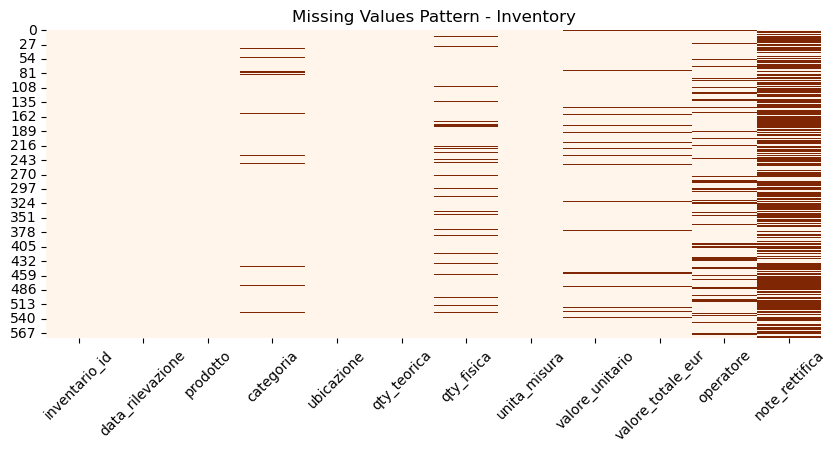

In [7]:
# NaN visual
plt.figure(figsize=(10,4))
sns.heatmap(inventory.isna(),cbar=False, cmap='Oranges')
plt.title("Missing Values Pattern - Inventory")
plt.xticks(rotation=45)
plt.show()

#### Date Accuracy

In [8]:
date_accuracy(inventory, 'data_rilevazione', [2023, 2024])

0 rows out of range found.
[]


#### Basic Cleaning

In [9]:
inventory_cleaned = basic_cleaning(inventory, MAPPING_DICT)


#### Fuzzy Match time

In [10]:
fuzzy_map_inventory = get_best_match(inventory_cleaned['prodotto'], benchmark_cleaned['Ingrediente_Standard'], threshold=70)
inventory_cleaned['nome_standard'] = inventory_cleaned['prodotto'].map(fuzzy_map_inventory)

# checking NaN - not matched names
mask = inventory_cleaned['nome_standard'].isna()
inventory_fuzzy_nan = inventory_cleaned.loc[mask].copy()
display(inventory_fuzzy_nan.drop_duplicates(subset=['prodotto']))

Failed matches: 4/24


,inventario_id,data_rilevazione,prodotto,categoria,ubicazione,qty_teorica,qty_fisica,unita_misura,valore_unitario,valore_totale_eur,operatore,note_rettifica,anno,nome_standard
17,70018,2023-01-31,chianti docg bt,vini,dispensa,36.107,36.880,bt,6.5353,241.02,adm,NaN,2023,<NA>
18,70019,2023-01-31,tignanello,vini,bancone,14.207,15.110,bt,75.2202,1136.58,operatore,NaN,2023,<NA>
19,70020,2023-01-31,prosecco,vini,dispensa,20.365,20.365,bt,4.4152,89.92,anna,NaN,2023,<NA>
20,70021,2023-01-31,acqua nat 1l,bevande,cantina,77.497,77.497,pz,NaN,NaN,anna,NaN,2023,<NA>


#### Fixing quantities errors

In [11]:
inventory_fixed = fix_unit_errors(inventory_cleaned, 'unita_misura', 'valore_unitario', 'nome_standard', 'categoria', 10, PREMIUM_CATEGORIES, SAFE_CATEGORIES)
inventory_fixed['unita_misura'].unique()

BUSINESS RULE: No unit error (g -> kg) found.


array(['kg', 'cassa', 'pz', 'l', 'lt', 'bt'], dtype=object)

#### Quantity Standardizing

In [12]:
inventory_cleaned_std = standardize_quantities(inventory_fixed, qty_cols=['qty_fisica', 'qty_teorica'], unit_col='unita_misura')

# managing eggs 'cassa' quantity
cassa = inventory_cleaned_std['unita_misura'] == 'cassa'
inventory_cleaned_std.loc[cassa, ['qty_teorica','qty_fisica']] *= 1.8 
inventory_cleaned_std.loc[cassa, 'valore_unitario'] /= 1.8
inventory_cleaned_std.loc[cassa, 'unita_misura'] = 'kg'

#### Quantity Conversion

In [13]:
inventory_cleaned_std = quantity_exception_manage(inventory_cleaned_std,'nome_standard', 'qty_fisica', 'unita_misura', conversion_map= CONVERSION_MAP, price_col ='valore_unitario')
inventory_cleaned_std = quantity_exception_manage(inventory_cleaned_std,'nome_standard', 'qty_teorica', 'unita_misura', conversion_map= CONVERSION_MAP, price_col ='valore_unitario')

Converted 24 rows of burrata from pz to kg
No conversion applied. Verify that the names and units match.


#### Outlier Detection

inventario_id: 0 found
qty_teorica: 31 found
qty_fisica: 30 found
valore_unitario: 16 found
valore_totale_eur: 24 found


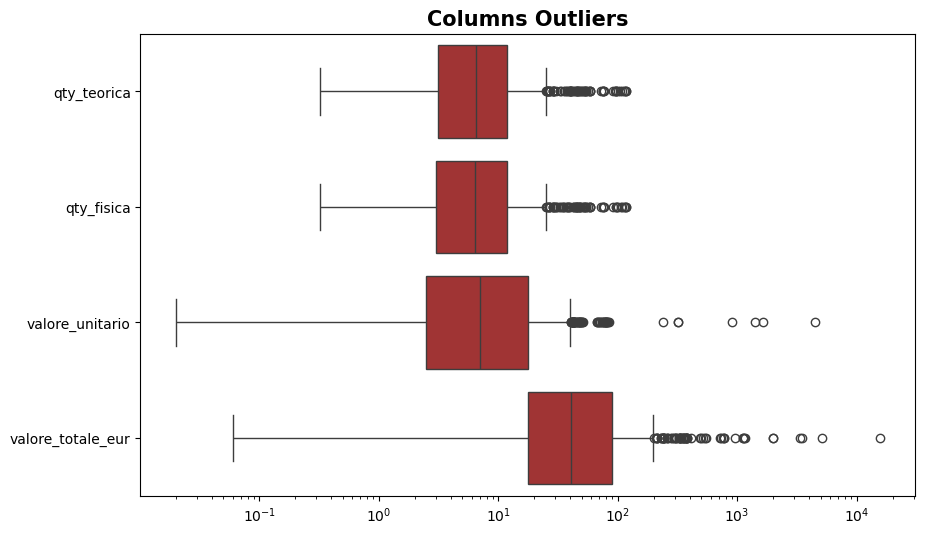

,inventario_id,data_rilevazione,prodotto,categoria,ubicazione,qty_teorica,qty_fisica,unita_misura,valore_unitario,valore_totale_eur,operatore,note_rettifica,anno,nome_standard
414,70415,2024-06-28,porcini fr.,funghi,surgelati,1.15,1.15,kg,4500.0,5175.00,mario,NaN,2024,funghi porcini freschi
275,70276,2023-12-28,parmigiano 24m,latticini,cella pesce,9.57,9.57,kg,1650.0,15783.90,luigi b.,verificato,2023,parmigiano reggiano dop 24m
341,70342,2024-03-28,vongole,pesce,cantina,3.70,3.70,kg,900.0,3330.90,NaN,verificato,2024,vongole veraci fresche
247,70248,2023-11-28,pomodorini,verdure,bancone,1.53,NaN,kg,320.0,490.88,anna,ok,2023,pomodorini ciliegino
469,70470,2024-08-28,panna fresca,latticini,dispensa,9.04,8.27,lt,240.0,1984.32,mario.r,ok,2024,panna fresca liquida


In [14]:
# calling function defined in a variable
out = ouliers_auto_detection(inventory_cleaned_std, 4)

# have a quick look on outliers
inventory_cleaned_std.loc[out]

# defining new condition to exclude Beverage
food_mask = ~inventory_cleaned_std['categoria'].isin(['vini', 'bevande'])
new_mask = out & food_mask
inventory_outliers = inventory_cleaned_std.loc[new_mask].copy()
display(inventory_outliers[inventory_outliers['valore_unitario'] > 90].sort_values(ascending=False, by='valore_unitario').dropna(subset='categoria').drop_duplicates(subset=['valore_unitario']))

#### Fixing Wrong Prices

In [15]:
# converting outliers to NaN 
inventory_cleaned_std.loc[new_mask, 'valore_unitario'] = np.nan

# extratcing prices from benchmark_table
benchmark_dict = dict(zip(benchmark_cleaned['Ingrediente_Standard'],  benchmark_cleaned['Prezzo_Benchmark_EUR']))

# filling NaN with benchmark prices
inventory_cleaned_std.loc[new_mask, 'valore_unitario'] = inventory_cleaned_std['nome_standard'].map(benchmark_dict)

# quick view on changes
inventory_outliers_2= inventory_cleaned_std.loc[new_mask].copy()
display(inventory_outliers_2[['prodotto', 'categoria', 'unita_misura', 'valore_unitario', 'valore_totale_eur']].dropna(subset='categoria').sort_values(ascending=False, by='valore_unitario').drop_duplicates(subset=['valore_unitario']))

# recalculating importo_finale


,prodotto,categoria,unita_misura,valore_unitario,valore_totale_eur
414,porcini fr.,funghi,kg,45.0,5175.00
217,costata di manzo,carni,kg,30.0,514.82
275,parmigiano 24m,latticini,kg,16.5,15783.90
341,vongole,pesce,kg,8.5,3330.90
247,pomodorini,verdure,kg,3.2,490.88
469,panna fresca,latticini,lt,2.4,1984.32


#### Descriptive Stats

In [16]:
print("INVENTORY STATS")
print(f"Period: {inventory['data_rilevazione'].min()} → {inventory['data_rilevazione'].max()}")
print(f"Unic Products: {inventory['prodotto'].nunique()}")
print(f"Average Shrinkage: {(inventory['qty_fisica'] - inventory['qty_teorica']).mean():.2f}")

# Distribuzione per categoria
print("\n Products per Category:")
print(inventory['categoria'].value_counts())

INVENTORY STATS
Period: 2023-01-31 → 31/01/2023
Unic Products: 24
Average Shrinkage: 0.21

 Products per Category:
categoria
Latticini     115
Carni          70
Secchi         70
Vini           70
Pesce          69
Verdure        46
Bevande        46
Condimenti     46
Funghi         24
Name: count, dtype: int64


### SALES POS TABLE

#### Checking NaN and Duplicates

In [17]:
# calling function
dupli_nan_count(sales_pos)

No duplicates

NaN values:


transazione_id            0
data_ora                  0
tavolo                    0
coperti                3216
item_name                 0
categoria              3277
quantita                  0
prezzo_unitario           0
totale_riga               0
operatore_id              0
modalita_pagamento    12781
note                  41832
dtype: int64

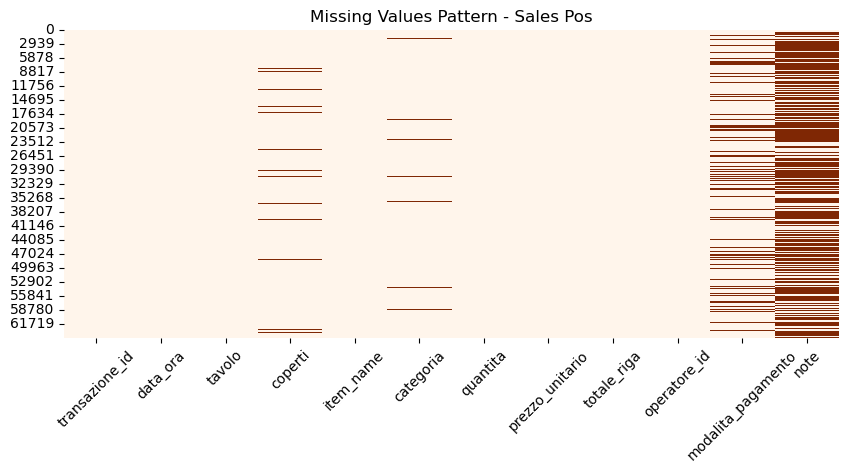

In [18]:
# NaN visual
plt.figure(figsize=(10,4))
sns.heatmap(sales_pos.isna(),cbar=False, cmap='Oranges')
plt.title("Missing Values Pattern - Sales Pos")
plt.xticks(rotation=45)
plt.show()

#### Date Accuracy

In [19]:
date_accuracy(sales_pos, 'data_ora', [2023, 2024])

419 rows out of range found.
[2022 2033 2034 2025]


In [20]:
# FIXING DATA
sales_pos = sales_pos[sales_pos['anno'].isin([2023, 2024])]
sales_pos['anno'].unique()

array([2023, 2024], dtype=int32)

#### Basic Cleaning

In [21]:
sales_pos_cleaned = basic_cleaning(sales_pos, MAPPING_DICT)


#### Outlier Detection

transazione_id: 0 found
coperti: 0 found
quantita: 0 found
prezzo_unitario: 3088 found
totale_riga: 1548 found


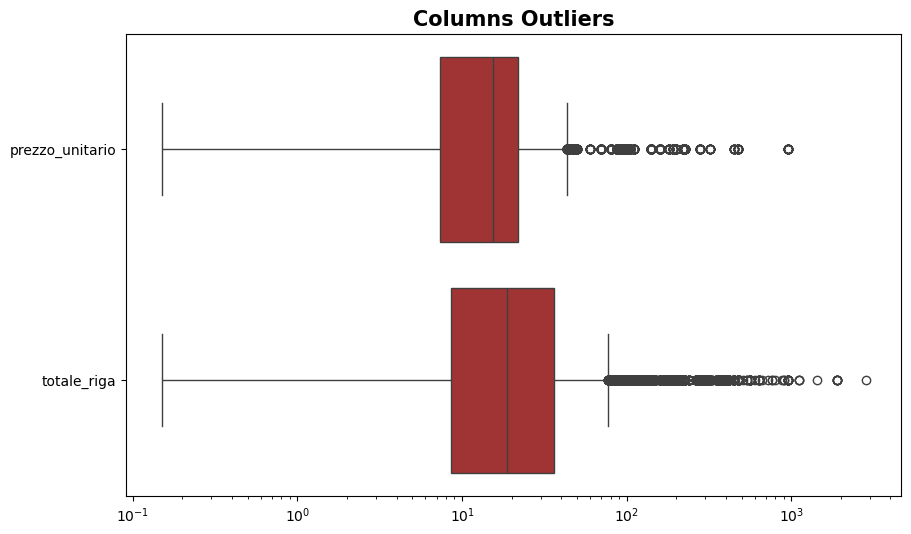

,item_name,prezzo_unitario
39250,bistecca alla fiorentina,450.0
50054,tagliata di manzo,320.0
27270,branzino al forn,280.0
20691,bistecca alla fiorentina,225.0
27277,cotoletta alla milanese,220.0
35045,spaghetti alle vongole,200.0
21163,pappardelle al cinghiale,190.0
32199,risotto ai funghi porcini,180.0
28129,tagliata di manzo,160.0
59214,ribollita toscana,140.0


In [22]:
# calling function defined in a variable
sales_pos_out = ouliers_auto_detection(sales_pos_cleaned, 4)

# have a quick look on outliers
sales_pos_cleaned.loc[sales_pos_out]

# defining new condition to exclude Beverage
sales_pos_food_mask = ~(sales_pos_cleaned['item_name'].isin(['vino tignanello bottiglia', 'vino tignanello bottigli','vino chianti bottiglia']) & sales_pos_cleaned['categoria'].isin(['bevande']))
sales_new_mask = sales_pos_out & sales_pos_food_mask
sales_pos_outliers = sales_pos_cleaned.loc[sales_new_mask].copy()
sales_pos_outliers = sales_pos_outliers.dropna(subset='categoria')
display(sales_pos_outliers[(sales_pos_outliers['prezzo_unitario'] > 30) & (sales_pos_outliers['quantita'] == 1)][['item_name', 'prezzo_unitario']].sort_values(ascending=False, by='prezzo_unitario').drop_duplicates(subset=['prezzo_unitario']))

#### Descriptive Stats

In [23]:
print("SALES POS STATS")
print(f"Period: {sales_pos_cleaned['data_ora'].min()} → {sales_pos_cleaned['data_ora'].max()}")
print(f"Unic Products: {sales_pos_cleaned['item_name'].nunique()}")

# Distribuzione per categoria
print("\n Products per Category:")
print(sales_pos_cleaned['categoria'].value_counts())

SALES POS STATS
Period: 2023-01-01 12:19:00 → 2024-12-31 22:58:00
Unic Products: 46

 Products per Category:
categoria
bevande      15918
primi        13168
antipasti    10766
secondi      10588
dolci         7899
extra         2643
Name: count, dtype: int64


### INVOICES TABLE

#### Checking NaN and Duplicates

In [24]:
# calling function
dupli_nan_count(invoices)

No duplicates

NaN values:


fattura_id                0
riga_fattura              0
data_fattura              0
fornitore                 0
codice_fornitore          0
codice_prodotto           0
descrizione_prodotto      0
categoria               128
quantita                  0
unita_misura              0
prezzo_unitario          67
importo_totale           67
iva_pct                  72
pagato                   37
data_scadenza            77
dtype: int64

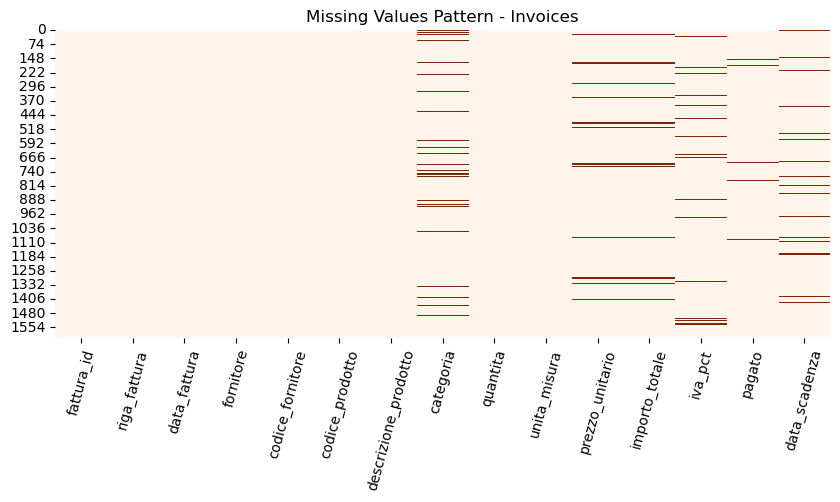

In [25]:
# NaN visual
plt.figure(figsize=(10,4))
sns.heatmap(invoices.isna(),cbar=False, cmap='Oranges')
plt.title("Missing Values Pattern - Invoices")
plt.xticks(rotation=75)
plt.show()

#### Date Accuracy

In [26]:
date_accuracy(invoices, 'data_fattura', [2023, 2024])

0 rows out of range found.
[]


#### Basic Cleaning

In [27]:
invoices_cleaned = basic_cleaning(invoices, MAPPING_DICT)


#### Fuzzy Match time

In [28]:
fuzzy_map_invoices = get_best_match(invoices_cleaned['descrizione_prodotto'], benchmark_cleaned['Ingrediente_Standard'], threshold=70)
invoices_cleaned['nome_standard'] = invoices_cleaned['descrizione_prodotto'].map(fuzzy_map_invoices)

# checking NaN - not matched names
invoices_mask = invoices_cleaned['nome_standard'].isna()
invoices_fuzzy_nan = invoices_cleaned.loc[invoices_mask].copy()
display(invoices_fuzzy_nan[['categoria', 'descrizione_prodotto', 'unita_misura', 'prezzo_unitario', 'nome_standard']].sort_values(by='prezzo_unitario', ascending=False).drop_duplicates(subset=['descrizione_prodotto']))

Failed matches: 11/63


,categoria,descrizione_prodotto,unita_misura,prezzo_unitario,nome_standard
643,NaN,prosecco doc,bt,240.0000,<NA>
529,vini,vino tignanello,bt,89.4638,<NA>
647,bevande,acqua 1000ml,nr,17.5000,<NA>
651,vini,vino chianti docg bt,1,7.7997,<NA>
601,vini,chianti bt 0.75,750ml,7.6689,<NA>
671,vini,chianti docg,750ml,7.5580,<NA>
822,vini,chianti 75cl,0.75,7.2954,<NA>
495,NaN,acqua nat 1l,cad,0.4167,<NA>
618,bevande,acqua minerale 1l,pezzi,0.4149,<NA>
51,bevande,acqua minerale,nr,0.4100,<NA>


In [29]:
invoices_cleaned['nome_standard'].dropna()

0             olio extravergine di oliva
1                              sale fino
2       insalata mista (iceberg/lattuga)
3             olio extravergine di oliva
4             lombata di manzo (costata)
                      ...               
1604                 latte intero fresco
1605                             burrata
1607              salmone fresco filetti
1608    insalata mista (iceberg/lattuga)
1609          lombata di manzo (costata)
Name: nome_standard, Length: 1372, dtype: object

#### Fixing Quantities

In [30]:
invoices_fixed = fix_unit_errors(invoices_cleaned, 'unita_misura', 'prezzo_unitario', 'descrizione_prodotto', 'categoria', 10, PREMIUM_CATEGORIES, SAFE_CATEGORIES)


BUSINESS RULE: Fixed 44 unit errors ('g' to 'kg') for products > 10€


#### Quantity Standardizing

In [31]:
invoices_cleaned_std = standardize_quantities(invoices_fixed, qty_cols='quantita', unit_col='unita_misura')
invoices_cleaned_std['unita_misura'].value_counts()

unita_misura
kg    1044
pz     208
bt     186
lt     172
Name: count, dtype: int64

In [32]:
non_std = invoices_cleaned_std['unita_misura'].isin(['pz'])
invoices_cleaned_std.loc[non_std]

,fattura_id,riga_fattura,data_fattura,fornitore,codice_fornitore,codice_prodotto,descrizione_prodotto,categoria,quantita,unita_misura,prezzo_unitario,importo_totale,iva_pct,pagato,data_scadenza,anno,nome_standard
12,50004,1,2023-01-12,ortofrutta rossi e figli,forn-003,sku-8544,burrata,NaN,265.0,pz,3.1727,840.77,4.0,si,2023-03-13,2023,burrata
23,50006,1,2023-01-16,cantina vinicola toscana,forn-004,sku-9617,acqua minerale 1l,NaN,131.0,pz,NaN,NaN,22.0,0,2023-04-16,2023,<NA>
41,50008,4,2023-01-22,ortofrutta rossi e figli,forn-003,sku-8463,chianti 75cl,vini,46.0,pz,7.0985,326.53,22.0,no,2023-02-21,2023,<NA>
46,50009,2,2023-01-25,cantina vinicola toscana,forn-004,sku-4448,uova fresche,latticini,218.0,pz,0.3324,72.46,22.0,0,2023-02-24,2023,uova
47,50009,3,2023-01-25,cantina vinicola toscana,forn-004,sku-8271,burrata,latticini,144.0,pz,3.3113,476.83,22.0,si,2023-03-26,2023,burrata
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1566,50279,8,2024-12-10,pescheria del mare snc,forn-002,sku-7862,uova fresche,latticini,283.0,pz,0.3186,90.16,22.0,si,2025-02-08,2024,uova
1590,50282,8,2024-12-19,distribuzione generale,forn-008,sku-3169,acqua 1000ml,bevande,152.0,pz,NaN,NaN,5.0,si,2025-01-18,2024,<NA>
1595,50284,1,2024-12-23,ortofrutta rossi e figli,forn-003,sku-8992,burrata,latticini,189.0,pz,2.9366,555.02,22.0,si,2025-01-22,2024,burrata
1598,50284,4,2024-12-23,ortofrutta rossi e figli,forn-003,sku-2243,uova fresche cat. a,latticini,86.0,pz,0.2754,23.68,NaN,si,2025-02-21,2024,uova


#### Quantity Conversion

In [33]:
invoices_cleaned_std = quantity_exception_manage(invoices_cleaned_std,'nome_standard', 'quantita', 'unita_misura', conversion_map= CONVERSION_MAP, price_col='prezzo_unitario')
non_std = invoices_cleaned_std['unita_misura'].isin(['pz'])
invoices_cleaned_std.loc[non_std]

Converted 56 rows of burrata from pz to kg
Converted 58 rows of uova from pz to kg
Converted 14 rows of panna fresca liquida from ['bt', '750ml', '0.75'] to lt


,fattura_id,riga_fattura,data_fattura,fornitore,codice_fornitore,codice_prodotto,descrizione_prodotto,categoria,quantita,unita_misura,prezzo_unitario,importo_totale,iva_pct,pagato,data_scadenza,anno,nome_standard
23,50006,1,2023-01-16,cantina vinicola toscana,forn-004,sku-9617,acqua minerale 1l,NaN,131.0,pz,NaN,NaN,22.0,0,2023-04-16,2023,<NA>
41,50008,4,2023-01-22,ortofrutta rossi e figli,forn-003,sku-8463,chianti 75cl,vini,46.0,pz,7.0985,326.53,22.0,no,2023-02-21,2023,<NA>
49,50009,5,2023-01-25,cantina vinicola toscana,forn-004,sku-7773,acqua nat 1l,bevande,156.0,pz,0.2991,46.66,22.0,no,2023-03-26,2023,<NA>
51,50010,2,2023-01-28,macelleria bianchi srl,forn-001,sku-9925,acqua minerale,bevande,86.0,pz,0.4100,35.26,22.0,1,2023-03-29,2023,<NA>
95,50019,4,2023-02-20,pescheria del mare snc,forn-002,sku-8101,vino tignanello,vini,47.0,pz,75.1429,3531.72,10.0,1,2023-05-21,2023,<NA>
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1486,50265,8,2024-11-07,ortofrutta rossi e figli,forn-003,sku-2936,acqua minerale,bevande,252.0,pz,0.3195,80.51,22.0,si,2024-12-07,2024,<NA>
1493,50266,7,2024-11-08,pescheria del mare snc,forn-002,sku-8861,acqua nat 1l,bevande,222.0,pz,0.3596,79.83,10.0,no,2025-01-07,2024,<NA>
1561,50279,3,2024-12-10,pescheria del mare snc,forn-002,sku-9586,vino tignanello,vini,7.0,pz,82.0320,574.22,10.0,si,2025-02-08,2024,<NA>
1565,50279,7,2024-12-10,pescheria del mare snc,forn-002,sku-2657,acqua minerale,bevande,278.0,pz,0.3034,84.35,4.0,s,2025-03-10,2024,<NA>


#### Outlier Detection

fattura_id: 0 found
riga_fattura: 0 found
quantita: 50 found
prezzo_unitario: 55 found
importo_totale: 82 found
iva_pct: 0 found


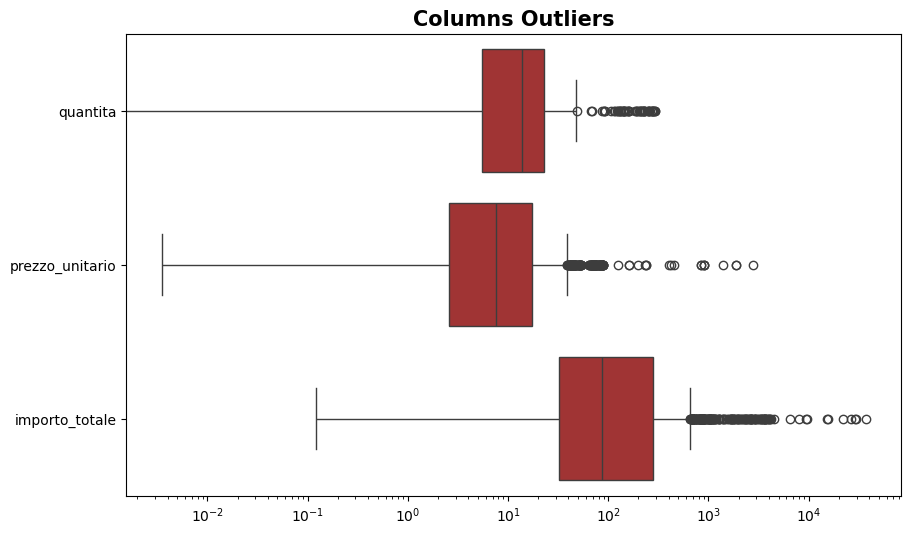

,codice_fornitore,codice_prodotto,descrizione_prodotto,categoria,quantita,unita_misura,prezzo_unitario
460,forn-008,sku-2406,costata di manzo,carni,10.59,kg,2800.000000
1081,forn-004,sku-1071,filetto di manzo,carni,19.74,kg,1900.000000
954,forn-004,sku-1561,vongole fresche,pesce,29.36,kg,900.000000
1120,forn-004,sku-6142,olio extravergine oliva,condimenti,9.51,lt,850.000000
1188,forn-005,sku-9202,vongole fresche,pesce,20.98,kg,450.000000
738,forn-003,sku-8943,petto di pollo,carni,5.33,kg,425.000000
622,forn-007,sku-6575,rucola,verdure,11.35,kg,400.000000
1048,forn-006,sku-9137,uova cat.a 30pz,latticini,15.84,kg,233.333333
1080,forn-004,sku-8506,rucola,verdure,13.39,kg,200.000000
946,forn-002,sku-9831,pomodorini ciliegino,verdure,23.29,kg,160.000000


In [34]:
# calling function defined in a variable
invoices_out = ouliers_auto_detection(invoices_cleaned_std, 4)

# have a quick look on outliers
invoices_cleaned_std.loc[invoices_out]

# defining new condition to exclude Beverage
invoices_food_mask = ~invoices_cleaned_std['categoria'].isin(['bevande', 'vini'])
invoices_new_mask = invoices_out & invoices_food_mask
invoices_outliers = invoices_cleaned_std.loc[invoices_new_mask].copy()
display(invoices_outliers[['codice_fornitore', 'codice_prodotto','descrizione_prodotto', 'categoria', 'quantita', 'unita_misura', 'prezzo_unitario']][invoices_outliers['prezzo_unitario'] > 50].dropna(subset='categoria').sort_values(ascending=False, by='prezzo_unitario').drop_duplicates(subset=['prezzo_unitario']))

#### Fixing Outliers Prices

In [35]:
# converting outliers to NaN 
invoices_cleaned_std.loc[invoices_new_mask, 'prezzo_unitario'] = np.nan

# filling NaN with benchmark prices
invoices_cleaned_std.loc[invoices_new_mask, 'prezzo_unitario'] = invoices_cleaned_std['nome_standard'].map(benchmark_dict)

# quick view on changes
invoices_outliers_2 = invoices_cleaned_std.loc[invoices_new_mask].copy()
display(invoices_outliers_2[['codice_fornitore', 'codice_prodotto','descrizione_prodotto', 'categoria', 'quantita', 'unita_misura', 'prezzo_unitario']][invoices_outliers['prezzo_unitario'] > 50].dropna(subset='categoria').sort_values(ascending=False, by='prezzo_unitario').drop_duplicates(subset=['prezzo_unitario']))

# recalculating importo_finale
invoices_cleaned_std['importo_totale_pulito'] = invoices_cleaned_std['prezzo_unitario'] * invoices_cleaned_std['quantita']

invoices_cleaned_std['unita_misura'].value_counts()

,codice_fornitore,codice_prodotto,descrizione_prodotto,categoria,quantita,unita_misura,prezzo_unitario
1377,forn-002,sku-8226,funghi porcini,funghi,27.17,kg,45.00
977,forn-001,sku-5395,filetto di manzo,carni,3.41,kg,38.00
460,forn-008,sku-2406,costata di manzo,carni,10.59,kg,30.00
1591,forn-002,sku-3606,branzino fresco,pesce,24.41,kg,18.00
954,forn-004,sku-1561,vongole fresche,pesce,29.36,kg,8.50
738,forn-003,sku-8943,petto di pollo,carni,5.33,kg,5.50
1048,forn-006,sku-9137,uova cat.a 30pz,latticini,15.84,kg,4.67
622,forn-007,sku-6575,rucola,verdure,11.35,kg,4.00
946,forn-002,sku-9831,pomodorini ciliegino,verdure,23.29,kg,3.20
533,forn-001,sku-8630,insalata mista,verdure,14.32,kg,2.00


unita_misura
kg    1158
lt     186
bt     172
pz      94
Name: count, dtype: int64

#### Descriptive Stats

In [36]:
print("INVOICES STATS")
print(f"Period: {invoices_cleaned_std['data_fattura'].min()} → {invoices_cleaned_std['data_fattura'].max()}")
print(f"Unic Products: {invoices_cleaned_std['descrizione_prodotto'].nunique()}")

# Distribuzione per categoria
print("\n Products per Category:")
print(invoices_cleaned_std['categoria'].value_counts())

INVOICES STATS
Period: 2023-01-03 00:00:00 → 2024-12-27 00:00:00
Unic Products: 63

 Products per Category:
categoria
latticini     300
carni         192
vini          180
secchi        177
pesce         176
verdure       172
condimenti    120
bevande       115
funghi         50
Name: count, dtype: int64


### RECIPES TABLE

#### Checking NaN and Duplicates

In [37]:
# calling function
dupli_nan_count(recipes)

No duplicates

NaN values:


ricetta_id                0
nome_piatto               0
ingrediente               0
quantita_per_porzione     0
unita_misura              0
note_chef                13
costo_stimato_eur         7
allergeni                46
dtype: int64

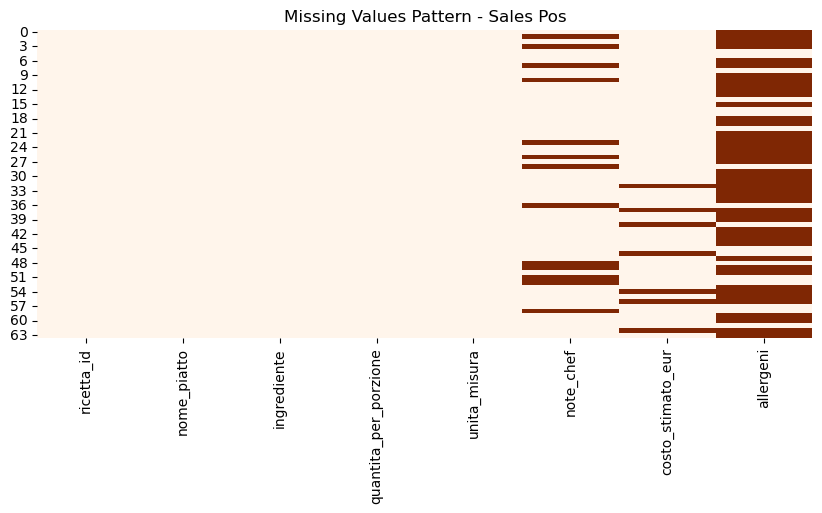

In [38]:
# NaN visual
plt.figure(figsize=(10,4))
sns.heatmap(recipes.isna(),cbar=False, cmap='Oranges')
plt.title("Missing Values Pattern - Sales Pos")
plt.show()

#### Basic Cleaning

In [39]:
recipes

,ricetta_id,nome_piatto,ingrediente,quantita_per_porzione,unita_misura,note_chef,costo_stimato_eur,allergeni
0,1,Risotto ai funghi porcini,Riso Carnaroli,0.080,kg,qty da aggiustare,2.1472,NaN
1,1,Risotto ai funghi porcini,PORCINI FRESCHI,0.050,kg,NaN,0.9344,NaN
2,1,Risotto ai funghi porcini,Cipolla bianca,0.020,kg,km0,0.2452,NaN
3,1,Risotto ai funghi porcini,Brodo vegetale,0.250,lt,NaN,1.7000,NaN
4,1,Risotto ai funghi porcini,Burro,0.015,kg,best quality,0.1385,latte
...,...,...,...,...,...,...,...,...
59,10,Cannolo siciliano,Gocce cioccolato fondente,0.015,kg,km0,0.5383,NaN
60,10,Cannolo siciliano,Zucchero a velo,0.010,kg,stagionale,0.3755,NaN
61,10,Cannolo siciliano,Marsala,0.010,l,qty da aggiustare,0.0958,solfiti
62,10,Cannolo siciliano,Cannella,0.001,kg,DOP,NaN,NaN


In [40]:
recipes_cleaned = basic_cleaning(recipes, MAPPING_DICT)


In [41]:
# DATA AUGMENTATION

data_augmentation = [
    # Cotoletta alla milanese
    {'nome_piatto': 'cotoletta alla milanese', 'ingrediente': 'fesa di vitello', 'quantita_per_porzione': 0.250, 'unita_misura': 'kg', 'costo_stimato_eur': 4.50},
    {'nome_piatto': 'cotoletta alla milanese', 'ingrediente': 'pangrattato', 'quantita_per_porzione': 0.060, 'unita_misura': 'kg', 'costo_stimato_eur': 0.15},
    {'nome_piatto': 'cotoletta alla milanese', 'ingrediente': 'uovo', 'quantita_per_porzione': 0.060, 'unita_misura': 'kg', 'costo_stimato_eur': 0.25},
    {'nome_piatto': 'cotoletta alla milanese', 'ingrediente': 'farina', 'quantita_per_porzione': 0.030, 'unita_misura': 'kg', 'costo_stimato_eur': 0.05},
    {'nome_piatto': 'cotoletta alla milanese', 'ingrediente': 'burro chiarificato', 'quantita_per_porzione': 0.050, 'unita_misura': 'kg', 'costo_stimato_eur': 0.60},
    
    # Tagliata di manzo
    {'nome_piatto': 'tagliata di manzo', 'ingrediente': 'controfiletto manzo', 'quantita_per_porzione': 0.300, 'unita_misura': 'kg', 'costo_stimato_eur': 7.50},
    {'nome_piatto': 'tagliata di manzo', 'ingrediente': 'rucola', 'quantita_per_porzione': 0.050, 'unita_misura': 'kg', 'costo_stimato_eur': 0.40},
    {'nome_piatto': 'tagliata di manzo', 'ingrediente': 'grana', 'quantita_per_porzione': 0.040, 'unita_misura': 'kg', 'costo_stimato_eur': 0.40},
    
    # Pappardelle al cinghiale
    {'nome_piatto': 'pappardelle al cinghiale', 'ingrediente': 'pappardelle fresche', 'quantita_per_porzione': 0.125, 'unita_misura': 'kg', 'costo_stimato_eur': 0.70},
    {'nome_piatto': 'pappardelle al cinghiale', 'ingrediente': 'ragu di cinghiale', 'quantita_per_porzione': 0.150, 'unita_misura': 'kg', 'costo_stimato_eur': 2.20},
    
    # Tagliere di salumi
    {'nome_piatto': 'tagliere di salumi', 'ingrediente': 'selezione salumi toscani', 'quantita_per_porzione': 0.150, 'unita_misura': 'kg', 'costo_stimato_eur': 3.50},
    {'nome_piatto': 'tagliere di salumi', 'ingrediente': 'sottoli', 'quantita_per_porzione': 0.050, 'unita_misura': 'kg', 'costo_stimato_eur': 0.70},
    {'nome_piatto': 'tagliere di salumi', 'ingrediente': 'pane', 'quantita_per_porzione': 0.100, 'unita_misura': 'kg', 'costo_stimato_eur': 0.30},
    
    # Bruschette miste
    {'nome_piatto': 'bruschette miste', 'ingrediente': 'pane casereccio', 'quantita_per_porzione': 0.100, 'unita_misura': 'kg', 'costo_stimato_eur': 0.30},
    {'nome_piatto': 'bruschette miste', 'ingrediente': 'pomodoro', 'quantita_per_porzione': 0.150, 'unita_misura': 'kg', 'costo_stimato_eur': 1.20},
    
    # Ribollita toscana
    {'nome_piatto': 'ribollita toscana', 'ingrediente': 'verdure', 'quantita_per_porzione': 0.200, 'unita_misura': 'kg', 'costo_stimato_eur': 1.00},
    {'nome_piatto': 'ribollita toscana', 'ingrediente': 'fagioli', 'quantita_per_porzione': 0.150, 'unita_misura': 'kg', 'costo_stimato_eur': 0.80},
    {'nome_piatto': 'ribollita toscana', 'ingrediente': 'pane raffermo', 'quantita_per_porzione': 0.100, 'unita_misura': 'kg', 'costo_stimato_eur': 0.20},
    {'nome_piatto': 'ribollita toscana', 'ingrediente': 'olio evo', 'quantita_per_porzione': 0.020, 'unita_misura': 'kg', 'costo_stimato_eur': 0.30}
]

# Creazione del DataFrame di augmentation
recipes_augmented = pd.DataFrame(data_augmentation)

# Unione con le ricette originali
recipes_cleaned_aug = pd.concat([recipes_cleaned, recipes_augmented], ignore_index=True)


In [42]:
recipes_cleaned_std = standardize_quantities(recipes_cleaned_aug, qty_cols='quantita_per_porzione', unit_col='unita_misura')

#checking results
recipes_cleaned_std['unita_misura'].value_counts()

unita_misura
kg    65
lt    17
pz     1
Name: count, dtype: int64

In [43]:
# standardizing all quantities
mask = recipes_cleaned_std['unita_misura'] == 'pz'
recipes_cleaned_std.loc[mask, 'unita_misura'] = 'kg'
mask_2 = recipes_cleaned_std['ingrediente'] == 'burrata pugliese'
recipes_cleaned_std.loc[mask_2]

,ricetta_id,nome_piatto,ingrediente,quantita_per_porzione,unita_misura,note_chef,costo_stimato_eur,allergeni
40,7.0,burrata con pomodorini,burrata pugliese,0.12,kg,dop,NaN,latte


#### Fuzzy Matching

In [44]:
fuzzy_map_recipes = get_best_match(recipes_cleaned_std['ingrediente'], benchmark_cleaned['Ingrediente_Standard'], threshold=70)
recipes_cleaned_std['nome_standard'] = recipes_cleaned_std['ingrediente'].map(fuzzy_map_recipes)

# checking NaN - not matched names
mask = recipes_cleaned_std['nome_standard'].isna()
recipes_fuzzy_nan = recipes_cleaned_std.loc[mask].copy()
display(recipes_fuzzy_nan.drop_duplicates(subset=['ingrediente']))

# dropping NaN on nome_standard and allergeni
recipes_cleaned_std.dropna(subset=['nome_standard'])

Failed matches: 10/78


,ricetta_id,nome_piatto,ingrediente,quantita_per_porzione,unita_misura,note_chef,costo_stimato_eur,allergeni,nome_standard
39,6.0,carpaccio di manzo,sale e pepe,0.00,kg,stagionale,0.0163,NaN,<NA>
68,NaN,cotoletta alla milanese,burro chiarificato,0.05,kg,NaN,0.6000,NaN,<NA>
73,NaN,pappardelle al cinghiale,ragu di cinghiale,0.15,kg,NaN,2.2000,NaN,<NA>
74,NaN,tagliere di salumi,selezione salumi toscani,0.15,kg,NaN,3.5000,NaN,<NA>
75,NaN,tagliere di salumi,sottoli,0.05,kg,NaN,0.7000,NaN,<NA>
77,NaN,bruschette miste,pane casereccio,0.10,kg,NaN,0.3000,NaN,<NA>
79,NaN,ribollita toscana,verdure,0.20,kg,NaN,1.0000,NaN,<NA>
80,NaN,ribollita toscana,fagioli,0.15,kg,NaN,0.8000,NaN,<NA>
81,NaN,ribollita toscana,pane raffermo,0.10,kg,NaN,0.2000,NaN,<NA>
82,NaN,ribollita toscana,olio evo,0.02,kg,NaN,0.3000,NaN,<NA>


,ricetta_id,nome_piatto,ingrediente,quantita_per_porzione,unita_misura,note_chef,costo_stimato_eur,allergeni,nome_standard
0,1.0,risotto ai funghi porcini,riso carnaroli,0.08,kg,qty da aggiustare,2.1472,NaN,riso carnaroli
1,1.0,risotto ai funghi porcini,porcini freschi,0.05,kg,NaN,0.9344,NaN,funghi porcini freschi
2,1.0,risotto ai funghi porcini,cipolla bianca,0.02,kg,km0,0.2452,NaN,cipolla dorata
3,1.0,risotto ai funghi porcini,brodo vegetale,0.25,lt,NaN,1.7000,NaN,brodo vegetale granulare
4,1.0,risotto ai funghi porcini,burro,0.02,kg,best quality,0.1385,latte,burro pastorizzato
...,...,...,...,...,...,...,...,...,...
70,NaN,tagliata di manzo,rucola,0.05,kg,NaN,0.4000,NaN,rucola
71,NaN,tagliata di manzo,grana,0.04,kg,NaN,0.4000,NaN,grana padano dop
72,NaN,pappardelle al cinghiale,pappardelle fresche,0.12,kg,NaN,0.7000,NaN,cozze fresche
76,NaN,tagliere di salumi,pane,0.10,kg,NaN,0.3000,NaN,pane a fette


#### Outlier Detection

ricetta_id: 0 found
quantita_per_porzione: 2 found
costo_stimato_eur: 4 found


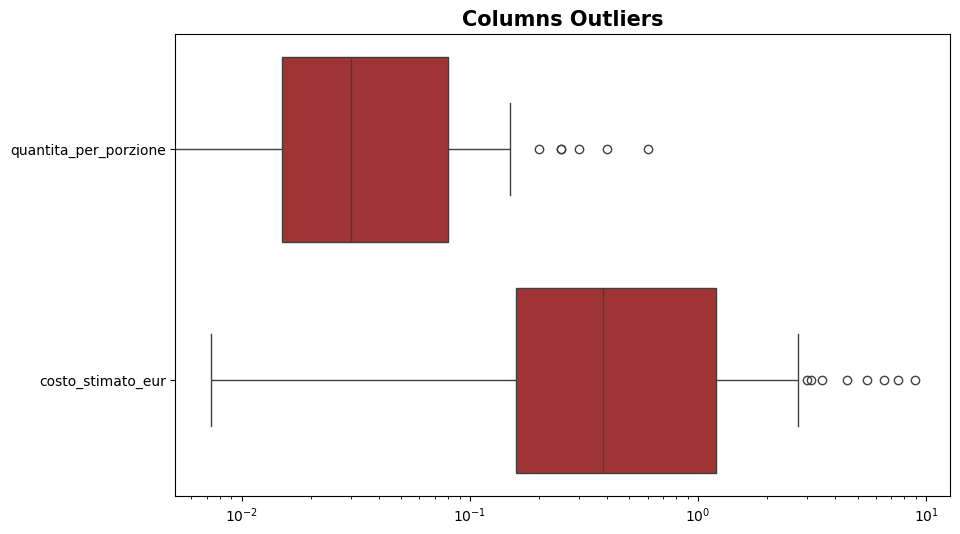

,ingrediente,quantita_per_porzione,costo_stimato_eur
28,branzino fresco intero,0.40,8.9478
69,controfiletto manzo,0.30,7.5000
23,costata t-bone manzo,0.60,6.5224
52,panna fresca liquida,0.15,5.5193


In [45]:
# calling function defined in a variable
recipes_out_mask = ouliers_auto_detection(recipes_cleaned_std, 4)

# defining new condition to exclude Beverage
recipes_outliers = recipes_cleaned_std.loc[recipes_out_mask].copy()
display(recipes_outliers[['ingrediente', 'quantita_per_porzione','costo_stimato_eur']].sort_values(ascending=False, by='costo_stimato_eur').drop_duplicates(subset=['costo_stimato_eur']))

#### Managing Outrange Price

In [46]:
recipes_cleaned_std['prezzo_benchmark_eur'] = recipes_cleaned_std['nome_standard'].map(benchmark_dict).fillna(recipes_cleaned_std['costo_stimato_eur'])

#### Descriptive Stats

In [47]:
print("RECIPES STATS")
print(f"Unic Products: {recipes_cleaned_std['ingrediente'].nunique()}")
print(f"Unic Products: {recipes_cleaned_std['nome_piatto'].nunique()}")

RECIPES STATS
Unic Products: 78
Unic Products: 16


In [48]:
# OPERETING ON RECIPES TABLE
display(recipes['ingrediente'].value_counts(dropna=False))
display(recipes['unita_misura'].value_counts(dropna=False))
display(recipes['quantita_per_porzione'].value_counts(dropna=False))

ingrediente
Sale                      3
Olio EVO                  2
Riso Carnaroli            1
Savoiardi                 1
Filetto manzo crudo       1
                         ..
Rosmarino fresco          1
Olio extravergine         1
Pepe nero macinato        1
Branzino fresco intero    1
Olio semi frittura        1
Name: count, Length: 61, dtype: int64

unita_misura
kg    45
l     14
lt     3
Kg     1
pz     1
Name: count, dtype: int64

quantita_per_porzione
0.015    8
0.020    7
0.010    6
0.005    6
0.080    4
0.001    4
0.050    4
0.040    3
0.002    3
0.060    3
0.025    2
0.003    2
0.150    2
0.030    2
0.090    2
0.600    1
0.400    1
0.120    1
0.125    1
0.250    1
0.035    1
Name: count, dtype: int64

### COME FUNZIONA .LOC[]
Il motivo per cui c'è una virgola e ci sono due valori dentro le parentesi quadre di .loc[] è che Pandas usa un sistema a coordinate, esattamente come la Battaglia Navale: <br>
• dataset.loc[ [QUALI_RIGHE_VOGLIO] , [QUALI_COLONNE_VOGLIO] ] <br>
Una volta che Pandas ha isolato le righe giuste, ti chiederebbe: "Ok, ho trovato le righe della Costata sana. Ma il tuo dataset ha 15 colonne (data, fornitore, iva, ecc.). Quale colonna ti serve di queste righe?"<br>
Scrivendo 'prezzo_unitario' dopo la virgola, gli stai dicendo: "Di quelle righe che hai appena filtrato, isolami solo la cella che sta sotto la colonna del prezzo". <br>
A quel punto, aggiungendo .mean() alla fine, lui calcola la media esclusivamente di quelle celle esatte. (e quindi la media della colonna prezzo_unitario)


_________________________

--------------------

-------------------

## EBITDA LEAK

In [49]:
invoices_cleaned_std['unita_misura'].value_counts()

unita_misura
kg    1158
lt     186
bt     172
pz      94
Name: count, dtype: int64

In [50]:
# creating period month for "data_fattura" column, so we can group purchases correctly and avoid duplicated rows
invoices_cleaned_std['month'] = pd.to_datetime(invoices_cleaned_std['data_fattura']).dt.to_period('M')
# grouping invoices by nome_standard, prep table to merging
invoices_grouped = invoices_cleaned_std.groupby(['month', 'nome_standard','unita_misura']).agg({'quantita':'sum',
                                                                                    'prezzo_unitario':'mean',
                                                                                    'importo_totale_pulito':'sum'}).reset_index()
invoices_cleaned_std['unita_misura'].value_counts()

unita_misura
kg    1158
lt     186
bt     172
pz      94
Name: count, dtype: int64

### **Perché facciamo il merge? <br>**
L'obiettivo finale è calcolare il Food Cost e lo Scostamento (EBITDA Leak).<br> 
Per farlo, abbiamo bisogno di un'unica tabella dove, per ogni prodotto, sappiamo:<br>
• Quanta giacenza abbiamo (dall'Inventario).<br>
• Qual è il suo prezzo unitario di riferimento (dalle Fatture).

In [51]:
# filtering needed columns from inventory
inventory_filtered = inventory_cleaned_std.drop(columns=['categoria', 'ubicazione', 'operatore', 'note_rettifica'])

# adding period_M to match date between both tables
inventory_filtered['month'] = pd.to_datetime(inventory_filtered['data_rilevazione']).dt.to_period('M')

# Merging both cleaned tables 
final_table = pd.merge(inventory_filtered, invoices_grouped, how='left', on=['nome_standard', 'month', 'unita_misura'])
# faccio il right perchè abbiamo bisogno come tabella di riferimento la tabella inventario per metterla in confronto con quella degli invoices
len(final_table)
final_table

,inventario_id,data_rilevazione,prodotto,qty_teorica,qty_fisica,unita_misura,valore_unitario,valore_totale_eur,anno,nome_standard,month,quantita,prezzo_unitario,importo_totale_pulito
0,70001,2023-01-31,filetto manzo,3.92,3.92,kg,NaN,NaN,2023,filetto di manzo,2023-01,5.35,38.000000,203.300000
1,70002,2023-01-31,costata di manzo,3.15,3.15,kg,NaN,NaN,2023,lombata di manzo (costata),2023-01,54.27,30.260467,1576.453392
2,70003,2023-01-31,pollo petto,9.73,8.94,kg,8.9051,79.57,2023,petto di pollo,2023-01,NaN,NaN,NaN
3,70004,2023-01-31,branzino,1.99,2.14,kg,18.3269,39.24,2023,branzino fresco,2023-01,NaN,NaN,NaN
4,70005,2023-01-31,salmone fresco,6.09,6.09,kg,15.9959,97.38,2023,salmone fresco filetti,2023-01,15.06,14.856800,223.743408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
571,70572,2024-12-28,prosecco,28.91,28.91,bt,4.6665,134.93,2024,<NA>,2024-12,NaN,NaN,NaN
572,70573,2024-12-28,acqua nat 1l,109.14,109.14,pz,0.3592,39.20,2024,<NA>,2024-12,NaN,NaN,NaN
573,70574,2024-12-28,olio extravergine oliva,6.70,6.70,lt,8.3502,55.93,2024,olio extravergine di oliva,2024-12,37.30,7.966267,302.406518
574,70575,2024-12-28,sale fino,2.69,2.67,kg,0.3734,1.00,2024,sale fino,2024-12,0.01,0.400000,0.004000


In [52]:
# checking NaN nature
final_table.isna().sum()
mask = final_table['nome_standard'].isna()

# nan items are baeically drinks, our focus is on food items
non_food = final_table['unita_misura'].isin(['bt', 'pz'])

# cheking if there is still any food items
non_food_items = final_table.loc[non_food]

final_table = final_table[~final_table.isin(non_food_items)]


In [53]:
# cleaning from non-match NaN
# filling the purchase gaps with 0s instead of deleting data that would distort the final result
final_table['quantita'] = final_table['quantita'].fillna(0)
final_table['importo_totale_pulito'] = final_table['importo_totale_pulito'].fillna(0)

# checking possible NaN value and final table head
print("Total NaN amount:")
print(final_table.isna().sum())
print('_' * 160)
final_table.head(10)

Total NaN amount:
inventario_id             96
data_rilevazione          96
prodotto                  96
qty_teorica               96
qty_fisica               141
unita_misura              96
valore_unitario          129
valore_totale_eur        129
anno                      96
nome_standard             96
month                     96
quantita                   0
prezzo_unitario          121
importo_totale_pulito      0
dtype: int64
________________________________________________________________________________________________________________________________________________________________


,inventario_id,data_rilevazione,prodotto,qty_teorica,qty_fisica,unita_misura,valore_unitario,valore_totale_eur,anno,nome_standard,month,quantita,prezzo_unitario,importo_totale_pulito
0,70001.0,2023-01-31,filetto manzo,3.920,3.920,kg,NaN,NaN,2023.0,filetto di manzo,2023-01,5.35,38.000000,203.300000
1,70002.0,2023-01-31,costata di manzo,3.150,3.150,kg,NaN,NaN,2023.0,lombata di manzo (costata),2023-01,54.27,30.260467,1576.453392
2,70003.0,2023-01-31,pollo petto,9.730,8.940,kg,8.905100,79.57,2023.0,petto di pollo,2023-01,0.00,NaN,0.000000
3,70004.0,2023-01-31,branzino,1.990,2.140,kg,18.326900,39.24,2023.0,branzino fresco,2023-01,0.00,NaN,0.000000
4,70005.0,2023-01-31,salmone fresco,6.090,6.090,kg,15.995900,97.38,2023.0,salmone fresco filetti,2023-01,15.06,14.856800,223.743408
5,70006.0,2023-01-31,vongole,3.060,3.060,kg,9.800400,30.02,2023.0,vongole veraci fresche,2023-01,0.01,9.000000,0.090000
6,70007.0,2023-01-31,porcini fr.,1.430,2.090,kg,49.961500,104.47,2023.0,funghi porcini freschi,2023-01,41.37,29.711800,715.165086
7,70008.0,2023-01-31,pomodorini,4.900,6.440,kg,3.577900,23.03,2023.0,pomodorini ciliegino,2023-01,25.52,3.064650,74.763857
8,70009.0,2023-01-31,rucola,0.380,0.360,kg,4.279700,1.53,2023.0,rucola,2023-01,0.03,4.000000,0.120000
9,70010.0,2023-01-31,uova fresche,18.864,18.864,kg,4.533278,85.55,2023.0,uova,2023-01,30.96,4.838333,146.426800


Adesso l'obiettivo è tracciare il movimento di un prodotto, ad esempio il "Filetto di manzo", tra due conteggi di inventario (uno all'inizio del mese e uno alla fine).

Per capire quanto ne è stato usato, dobbiamo mettere insieme tre elementi:

• Giacenza Iniziale: Quello che avevi già in casa il primo giorno.

• Acquisti: Quello che è arrivato con le fatture durante il periodo.

• Giacenza Finale: Quello che hai contato fisicamente oggi nello scaffale.

In [54]:
# imputing benchmark product price to NaN valore_unitario
final_table = imputing_benchmark_price(final_table, 'valore_unitario', 'nome_standard', 'prezzo_unitario')

In [55]:
# dropping NaN in qty_fisica
final_table = final_table.dropna(subset='qty_fisica')

# calculating missing value in valore_totale_EUR column
final_table.loc[:,'valore_totale_eur'] = final_table['qty_fisica'] * final_table['valore_unitario']

In [56]:
# IN CASO DI QTY FISICA MANCANTE, AGGIUNGERE UNA COLONNA FLAG LASCIANDO I NAN
# final_table['flag_column'] = final_table['qty_fisica'].map(lambda x: 'da ricontrollare' if pd.isna(x) else 'ok')

# MA MEGLIO ANCORA
# final_table['flag_column'] = np.where(final_table['qty_fisica'].isna(), 'da rincontrollare', 'ok')

In [57]:
display(final_table)

print("_"*120 + "\nValue Counts:")

final_table['nome_standard'].value_counts()

,inventario_id,data_rilevazione,prodotto,qty_teorica,qty_fisica,unita_misura,valore_unitario,valore_totale_eur,anno,nome_standard,month,quantita,prezzo_unitario,importo_totale_pulito
0,70001.0,2023-01-31,filetto manzo,3.92,3.92,kg,38.000000,148.960000,2023.0,filetto di manzo,2023-01,5.35,38.000000,203.300000
1,70002.0,2023-01-31,costata di manzo,3.15,3.15,kg,30.260467,95.320470,2023.0,lombata di manzo (costata),2023-01,54.27,30.260467,1576.453392
2,70003.0,2023-01-31,pollo petto,9.73,8.94,kg,8.905100,79.611594,2023.0,petto di pollo,2023-01,0.00,NaN,0.000000
3,70004.0,2023-01-31,branzino,1.99,2.14,kg,18.326900,39.219566,2023.0,branzino fresco,2023-01,0.00,NaN,0.000000
4,70005.0,2023-01-31,salmone fresco,6.09,6.09,kg,15.995900,97.415031,2023.0,salmone fresco filetti,2023-01,15.06,14.856800,223.743408
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,70568.0,2024-12-28,riso carnaroli,9.26,9.26,kg,3.272000,30.298720,2024.0,riso carnaroli,2024-12,24.05,3.636700,87.462635
568,70569.0,2024-12-28,pasta tagliatelle,9.05,9.86,kg,1.980100,19.523786,2024.0,pasta fresca tagliatelle,2024-12,14.87,2.088600,30.719814
573,70574.0,2024-12-28,olio extravergine oliva,6.70,6.70,lt,8.350200,55.946340,2024.0,olio extravergine di oliva,2024-12,37.30,7.966267,302.406518
574,70575.0,2024-12-28,sale fino,2.69,2.67,kg,0.373400,0.996978,2024.0,sale fino,2024-12,0.01,0.400000,0.004000


________________________________________________________________________________________________________________________
Value Counts:


nome_standard
farina 00                      24
caffe                          23
salmone fresco filetti         23
funghi porcini freschi         23
riso carnaroli                 23
parmigiano reggiano dop 24m    23
latte intero fresco            22
sale fino                      22
olio extravergine di oliva     22
pomodorini ciliegino           22
pasta fresca tagliatelle       22
lombata di manzo (costata)     22
filetto di manzo               21
vongole veraci fresche         21
petto di pollo                 21
burrata                        21
panna fresca liquida           20
uova                           20
rucola                         20
branzino fresco                20
Name: count, dtype: int64

In [58]:
sales_pos_cleaned

,transazione_id,data_ora,tavolo,coperti,item_name,categoria,quantita,prezzo_unitario,totale_riga,operatore_id,modalita_pagamento,note,anno
0,10001,2023-01-01 19:37:00,t7,2.0,cotoletta alla milanese,secondi,1,20.79,20.79,999,satispay,NaN,2023
1,10002,2023-01-01 13:21:00,t11,2.0,vino chianti bottiglia,bevande,2,30.14,60.28,marco_2,contanti,rettifica,2023
2,10003,2023-01-01 14:39:00,t7,4.0,acqua frizzante 1l,bevande,1,3.26,3.26,anna_04,carta,NaN,2023
3,10004,2023-01-01 13:44:00,terrazza,4.0,panna cotta frutti bosco,dolci,1,7.89,7.89,marco_2,NaN,NaN,2023
4,10005,2023-01-01 13:25:00,asporto,6.0,burrata con pomodorini,antipasti,1,14.84,14.84,operatore,carta,NaN,2023
...,...,...,...,...,...,...,...,...,...,...,...,...,...
64649,74650,2024-12-31 21:49:00,t9,2.0,vino tignanello bottiglia,bevande,2,100.71,201.42,999,bancomat,errore cassa,2024
64650,74651,2024-12-31 19:52:00,t14,2.0,carpaccio di manzo,antipasti,1,17.05,17.05,marco_02,carta,NaN,2024
64651,74652,2024-12-31 19:31:00,asporto,NaN,bruschette miste,antipasti,2,9.32,18.64,marco_02,NaN,omaggio,2024
64652,74653,2024-12-31 13:00:00,asporto,2.0,bruschette miste,antipasti,1,9.55,9.55,g03,contanti,rettifica,2024


In [59]:
sales_pos_cleaned = sales_pos_cleaned[sales_pos_cleaned['categoria'] != 'bevande']

In [60]:
# merging both table in order to have an exploded table, each plate in pos has its own ingrendients
final_df = pd.merge(sales_pos_cleaned, recipes_cleaned_std, left_on='item_name', right_on='nome_piatto', how='left')

# dropping useless columns
final_df = final_df.drop(columns=['tavolo', 'coperti', 'totale_riga', 'operatore_id', 'ricetta_id', 'categoria', 'modalita_pagamento', 'note', 'note_chef', 'allergeni'])

# checking NaN values
mask = final_df['prezzo_benchmark_eur'].isna()

# since nan value are at most "coperto" I easlily drop them
final_df.loc[mask].dropna() 


,transazione_id,data_ora,item_name,quantita,prezzo_unitario,anno,nome_piatto,ingrediente,quantita_per_porzione,unita_misura,costo_stimato_eur,nome_standard,prezzo_benchmark_eur


### EBITDA LEAK - Calcolo Finale

In [61]:
# calling final_table e final _df, in which we have inventory/invoices and sales/recipes
print("FINAL TABLE (Inventory + Incoives) :")
display(final_table.head(1))
print("_"*170)
print("FINAL DF (Sales_POS + Recpies):")
na_mask = final_df['nome_standard'].isna()
final_df.head(1)

FINAL TABLE (Inventory + Incoives) :


,inventario_id,data_rilevazione,prodotto,qty_teorica,qty_fisica,unita_misura,valore_unitario,valore_totale_eur,anno,nome_standard,month,quantita,prezzo_unitario,importo_totale_pulito
0,70001.0,2023-01-31,filetto manzo,3.92,3.92,kg,38.0,148.96,2023.0,filetto di manzo,2023-01,5.35,38.0,203.3


__________________________________________________________________________________________________________________________________________________________________________
FINAL DF (Sales_POS + Recpies):


,transazione_id,data_ora,item_name,quantita,prezzo_unitario,anno,nome_piatto,ingrediente,quantita_per_porzione,unita_misura,costo_stimato_eur,nome_standard,prezzo_benchmark_eur
0,10001,2023-01-01 19:37:00,cotoletta alla milanese,1,20.79,2023,cotoletta alla milanese,fesa di vitello,0.25,kg,4.5,fegato di vitello,11.0


### EBITDA LEAK QUANTITY COUNT

In [62]:
# 1. Calculating theorical quantity: quantità teorica utilizzata incrociando i piatti venduti con gli ingredienti per ogni piatto
final_df['total_theo_qty'] = final_df['quantita'] * final_df['quantita_per_porzione']  

# 2. Calculating theorical cost:
final_df['total_theo_cost'] = final_df['prezzo_benchmark_eur'] * final_df['total_theo_qty']
# I'd should use costo_stimato_eur from recipes table, but data are not realistic so I used benchmark price to calculate FC%

# 3. before calculating other stats it is important to group by transaction and plate
order_by_plate = final_df.groupby(['transazione_id', 'nome_piatto']).agg({
    'total_theo_cost': 'sum',      # Somma costi di TUTTI ingredienti
    'prezzo_unitario': 'first',    # Prezzo piatto (uguale per tutti ingredienti)
    'quantita': 'first'            # Numero piatti ordinati, utilizziamo la prima
}).reset_index()

# 4. Calculating total_revenue
order_by_plate['total_revenue'] = order_by_plate['quantita'] * order_by_plate['prezzo_unitario']

# 5. Calulating fc% each dish
order_by_plate['theo_fc_%'] = (order_by_plate['total_theo_cost'] / order_by_plate['total_revenue']) * 100

total_fc = (order_by_plate['total_theo_cost'].sum() / 
             order_by_plate['total_revenue'].sum()) * 100

print("FC% TEORICO TOTALE")
print(f"Costo totale: €{order_by_plate['total_theo_cost'].sum():,.2f}")
print(f"Revenue totale: €{order_by_plate['total_revenue'].sum():,.2f}")
print(f"FC% TEORICO: {total_fc:.1f}%")

# STEP 6: FC% medio per tipo di piatto
fc_per_piatto = order_by_plate.groupby('nome_piatto')['theo_fc_%'].agg(['mean', 'std', 'count']).round(2)

print(f"\n{'-'*47}")
print("FC% PER PIATTO (su tutti gli ordini)")
print(f"{'-'*47}")
print(fc_per_piatto.sort_values('mean', ascending=False))

FC% TEORICO TOTALE
Costo totale: €271,143.70
Revenue totale: €1,362,165.93
FC% TEORICO: 19.9%

-----------------------------------------------
FC% PER PIATTO (su tutti gli ordini)
-----------------------------------------------
                            mean    std  count
nome_piatto                                   
bistecca alla fiorentina   41.29  23.56   2675
tagliata di manzo          38.65  21.96   2712
carpaccio di manzo         32.97  22.00   2760
branzino al forno          28.29  14.76   2670
tiramisu                   25.56  14.56   2723
risotto ai funghi porcini  22.90  15.55   2650
burrata con pomodorini     22.79  14.06   2721
cotoletta alla milanese    15.04  10.16   2735
panna cotta frutti bosco   12.71   8.01   2726
cannolo siciliano          11.21   8.73   2643
tagliatelle al ragu        11.21   8.03   2652
spaghetti alle vongole      8.92   7.22   2741
bruschette miste            4.97   3.40   2809
tagliere di salumi          4.32   2.42   2779
pappardelle al cingh

In [63]:
# -- 6.-- Calculating REAL CONSUMPTION vs THEORICAL CONSUMPTION
 
# 6.1 Inventory offset: View on dates datas
final_table['data_rilevazione'].value_counts().sort_index().head(5)

# 6.2.1 Filtering on opening date and closing date 
opening_inventory = final_table['data_rilevazione'] == '2023-01-31'
closing_inventory = final_table['data_rilevazione'] == '2023-02-28'

# 6.2.2 Filtering on one month in order to have all monthly invoices 
monthly_invoices = final_table[final_table['data_rilevazione'] == '2023-02-28']

# 6.3 Summing qty_fisica (inventory) in opening/closing period
sum_qty_fisica_opening = final_table[opening_inventory].groupby('nome_standard')['qty_fisica'].sum().round(2).fillna(0)
sum_qty_fisica_closing = final_table[closing_inventory].groupby('nome_standard')['qty_fisica'].sum().round(2).fillna(0)

# 6.4 Summing quantity by product
sum_quantita = monthly_invoices.groupby('nome_standard')['quantita'].sum().round(2).fillna(0)
# uso .round(2) e non :.2f nella format string perchè non è un valore singolo ma una panda serie

# 6.5 Real Consumprion: Initial Stock + Invoices - Final Stock
real_consumption = sum_qty_fisica_opening.add(sum_quantita, fill_value=0).sub(sum_qty_fisica_closing, fill_value=0)

# 6.6 Calculating Theorical Consumption: grouping data
final_df['data_ora'] = pd.to_datetime(final_df['data_ora'])
theorical_closing_inventory = (final_df['data_ora'] >= '2023-02-01') & (final_df['data_ora'] < '2023-03-01')
theorical_consumption = final_df[theorical_closing_inventory].groupby('nome_standard')['total_theo_qty'].sum().round(2).fillna(0)

# 6.7 Final count
leak_qty = real_consumption.sub(theorical_consumption, fill_value=0)
leak_qty_c = leak_qty.copy()

# 6.8 filtering by Ingredinets qty
leak_qty_c = leak_qty_c[leak_qty_c != 0.00].sort_values(ascending=False)
leak_qty_c = pd.DataFrame(leak_qty_c).reset_index().rename(columns={'index':'nome_standard', 0 :'Total_qty'})

print('Stock count Net Qty Value: Real vs Theorical:')
leak_qty_c.head(10)

Stock count Net Qty Value: Real vs Theorical:


,nome_standard,Total_qty
0,farina 00,57.09
1,vongole veraci fresche,53.51
2,rucola,50.12
3,salmone fresco filetti,33.98
4,burrata,33.49
5,petto di pollo,20.14
6,panna fresca liquida,15.72
7,riso carnaroli,14.83
8,filetto di manzo,14.68
9,parmigiano reggiano dop 24m,13.24


**Valore > 0:** È merce che hai pagato e che è uscita dal frigo, ma che non ha generato fatturato (Spreco/Leak).

**Valore < 0:** (Se dovesse succedere) Significa che hai consumato meno di quanto previsto. Spesso indica che le porzioni in cucina sono più piccole di quanto scritto nella ricetta (potenziale calo della qualità).

### EBITDA LEAK EUR COUNT

In [64]:
# 1. Calculating weighted average price between quantity ordered and invoices price in order to keep price variation
wap = monthly_invoices.groupby('nome_standard')[['quantita', 'importo_totale_pulito']].agg({'quantita':'sum',
                                                                                      'importo_totale_pulito':'sum'}).round(2).reset_index()
wap['wap'] = (wap['importo_totale_pulito'] / wap['quantita']).round(2)

# 2. Merging wap column with leak quantity column
leak_eur = pd.merge(leak_qty_c, wap[['nome_standard', 'wap']], on='nome_standard', how='left')
missing_wap = leak_eur[leak_eur['wap'].isna()]

if len(missing_wap) > 0:
    print(f"{len(missing_wap)} ingredienti senza WAP:")
    print(missing_wap[['nome_standard', 'Total_qty']].sort_values(by='Total_qty').head(10))
    
    # Fallback with benchmark
    leak_eur.loc[leak_eur['wap'].isna(), 'wap'] = \
        leak_eur.loc[leak_eur['wap'].isna(), 'nome_standard'].map(benchmark_dict)

27 ingredienti senza WAP:
                    nome_standard  Total_qty
42       brodo vegetale granulare     -32.50
41        concentrato di pomodoro     -25.50
40              fegato di vitello     -24.00
39                  cozze fresche     -13.32
38                   pane a fette     -10.00
37  pasta secca (spaghetti/penne)      -9.81
35           pomodorini ciliegino      -8.55
34                     mascarpone      -8.48
33              macinato di manzo      -8.00
32                         limone      -7.61


In [65]:
# Se il WAP è NaN (perché non ci sono stati acquisti nel mese), usa il prezzo di benchmark!
leak_eur['wap'] = leak_eur['wap'].fillna(leak_eur['nome_standard'].map(benchmark_dict))

# Adesso il calcolo filerà liscio!
leak_eur['EBITDA_leak_eur'] = (leak_eur['Total_qty'] * leak_eur['wap']).round(2).sort_values(ascending=False)
leak_eur.head(10)

,nome_standard,Total_qty,wap,EBITDA_leak_eur
0,farina 00,57.09,0.89,50.81
1,vongole veraci fresche,53.51,9.67,517.44
2,rucola,50.12,4.24,212.51
3,salmone fresco filetti,33.98,16.45,558.97
4,burrata,33.49,23.62,791.03
5,petto di pollo,20.14,8.00,161.12
6,panna fresca liquida,15.72,2.70,42.44
7,riso carnaroli,14.83,3.33,49.38
8,filetto di manzo,14.68,36.23,531.86
9,parmigiano reggiano dop 24m,13.24,16.64,220.31


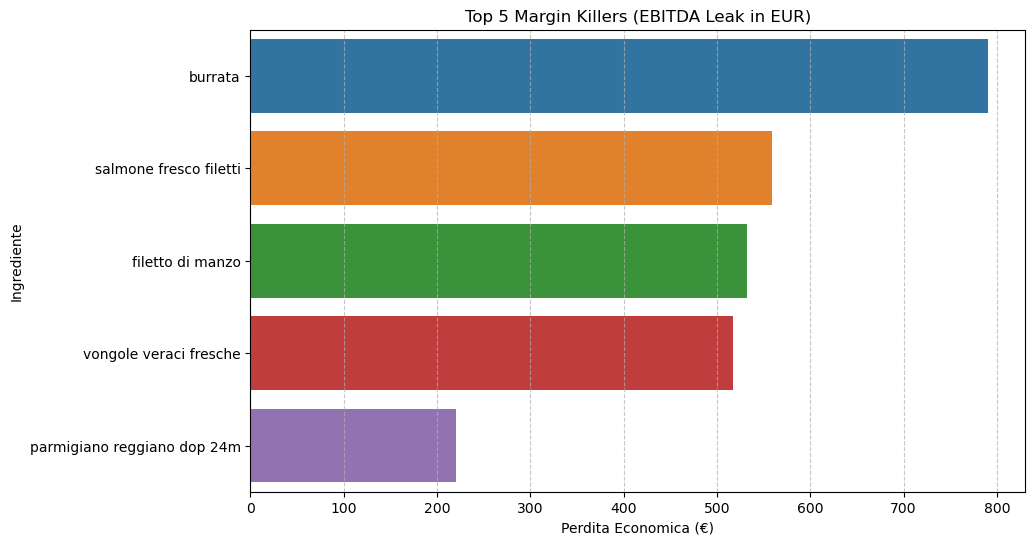

In [66]:
# Filtriamo i top 5 per valore assoluto dell'impatto economico
top_leaks = leak_eur.sort_values('EBITDA_leak_eur', ascending=False).head(5)

# Creazione del grafico
plt.figure(figsize=(10, 6))
sns.barplot(data=top_leaks, x='EBITDA_leak_eur', y='nome_standard', hue='nome_standard', legend=False)
plt.title('Top 5 Margin Killers (EBITDA Leak in EUR)')
plt.xlabel('Perdita Economica (€)')
plt.ylabel('Ingrediente')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [67]:
# Dopo calcolo EBITDA_leak_eur
print(f"\n{'-'*50}")
print("SUMMARY EBITDA LEAK")
print(f"{'-'*50}")
print(f"Total EBITDA leak: €{leak_eur['EBITDA_leak_eur'].sum():.2f}")
print(f"N° ingredients with leak: {len(leak_eur)}")
print(f"Missing WAP: {leak_eur['wap'].isna().sum()}")
print(f"Ingridients avarage leak: €{leak_eur['EBITDA_leak_eur'].mean():.2f}")

# Check outliers
top5 = leak_eur.nlargest(5, 'EBITDA_leak_eur')
print(f"\nTop 5 leak:")
for _, row in top5.iterrows():
    qty_kg = row['Total_qty']
    wap = row['wap']
    leak_eur = row['EBITDA_leak_eur']
    check = qty_kg * wap
    print(f"{row['nome_standard']:30s}: €{leak_eur:7,.2f} " 
          f"({qty_kg:.2f} kg × €{wap:.2f}) {'✓' if abs(check - leak_eur) < 0.01 else '❌'}")


--------------------------------------------------
SUMMARY EBITDA LEAK
--------------------------------------------------
Total EBITDA leak: €-740.27
N° ingredients with leak: 45
Missing WAP: 0
Ingridients avarage leak: €-16.45

Top 5 leak:
burrata                       : € 791.03 (33.49 kg × €23.62) ✓
salmone fresco filetti        : € 558.97 (33.98 kg × €16.45) ✓
filetto di manzo              : € 531.86 (14.68 kg × €36.23) ✓
vongole veraci fresche        : € 517.44 (53.51 kg × €9.67) ✓
parmigiano reggiano dop 24m   : € 220.31 (13.24 kg × €16.64) ✓


In [68]:
# AGGIUNGERE ROS - RETURN ON SALES: (EBIT / TOTAL REVENUE) * 100